# Viraltest v2 — Real LLM Training with LoRA + Environment Rewards

This notebook **actually trains** an LLM (Qwen2.5-1.5B-Instruct) to play our Instagram creator simulation.

**Pipeline:**
1. Clone repo & install deps
2. Run 5 heuristic baselines × 3 tasks (15 runs) → leaderboard
3. Run **untrained** LLM on all 3 tasks → "before" scores
4. **LoRA fine-tune** with reward-weighted SFT (4 rounds × 6 episodes = real weight updates)
5. Run **trained** LLM on all 3 tasks → "after" scores
6. Generate real plots from real numbers

**Requirements:** Colab T4 GPU (free tier), ~45 min total.

**What makes this real training:** LoRA adapter weights are actually updated via gradient descent. The model's behavior changes because its weights change, not because we edit the prompt.

**Before this notebook:** run `training/syntax_only.ipynb` (kernel + syntax only) and `training/train_grpo_smoke.ipynb` (repo + env). Pip lines use quoted package specs so Colab/zsh does not break on `>=`.

In [1]:
# Cell 1: Install dependencies (quote versions — zsh treats `>` as redirect otherwise)
!pip install -q torch torchvision torchaudio
!pip install -q "transformers>=4.45.0" "accelerate" "peft>=0.10.0" "trl>=0.20.0" "datasets"
!pip install -q matplotlib pandas
!pip install -q "typing_extensions>=4.13.0" pydantic httpx
!pip install -q "openenv-core[core]>=0.2.2"
!pip install -q flash-attn --no-build-isolation || echo "flash-attn install skipped; will use sdpa"

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      
      
      torch.__version__  = 2.5.1+cu124
      
      
      /tmp/pip-install-ldsack7d/flash-attn_09e25160e4bf4bbcbdb088cf5fe85bc6/setup.py:106: UserWarning: flash_attn was requested, but nvcc was not found.  Are you sure your environment has nvcc available?  If you're installing within a container from https://hub.docker.com/r/pytorch/pytorch, only images whose names contain 'devel' will provide nvcc.
        warnings.warn(
      Traceback (most recent call last):
        File "<string>", line 2, in <module>
        File "<pip-setuptools-caller>", line 34, in <module>
        File "/tmp/pip-install-ldsack7d/flash-attn_09e25160e4bf4bbcbdb088cf5fe85bc6/setup.py", line 227, in <module>
          CUDAExtension(
        File "/opt/conda/lib/python3.11/site-packages/torch/utils/cpp_extension.py", line 1078, in CUDAExtension
          library

flash-attn install skipped; will use sdpa


In [2]:
# Cell 2: Resolve repo path (Colab: fresh clone. Local: auto-detect project root)
import os
import sys
import shutil
import subprocess
from pathlib import Path

REPO_BRANCH = "main"
REPO_URL = "https://github.com/VaibhavKhandare/viral-posts-env.git"
COLAB_REPO = Path("/content/viral-posts-env")


def _is_repo_root(p: Path) -> bool:
    return (p / "server" / "viraltest_environment.py").is_file() and (p / "models.py").is_file()


def _find_local_root() -> Path:
    here = Path.cwd().resolve()
    for cand in (here, here.parent, here.parent.parent):
        if _is_repo_root(cand):
            return cand
    raise FileNotFoundError(
        "Could not find project root. cd into viral-posts-env or run this notebook in Google Colab."
    )


# --- Colab: always clone a clean copy (avoids stale 7-day code) ---
if Path("/content").is_dir():
    if COLAB_REPO.exists():
        shutil.rmtree(COLAB_REPO, ignore_errors=True)
    p = subprocess.run(
        [
            "git", "clone", "--branch", REPO_BRANCH, "--depth", "1",
            REPO_URL, str(COLAB_REPO),
        ],
        capture_output=True,
        text=True,
    )
    if p.returncode != 0:
        raise RuntimeError(
            "git clone failed. Check network and branch name.\n"
            f"stdout:\n{p.stdout}\nstderr:\n{p.stderr}"
        )
    if not COLAB_REPO.is_dir():
        raise FileNotFoundError(f"Clone did not create {COLAB_REPO}")
    os.chdir(COLAB_REPO)
    print("Mode: Colab (fresh clone)")
else:
    # --- Local machine: do not use /content ---
    root = _find_local_root()
    os.chdir(root)
    print("Mode: local")
    print(f"Repo root: {root}")

REPO_DIR = str(Path.cwd().resolve())
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

PLOTS_DIR = os.path.join(REPO_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

try:
    commit = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"],
        stderr=subprocess.DEVNULL,
        text=True,
    ).strip()
except Exception:
    commit = "n/a"

print(f"Working dir: {os.getcwd()}")
print(f"Branch: {REPO_BRANCH}")
print(f"Commit: {commit}")
print(f"Plots dir: {PLOTS_DIR}")

Mode: local
Repo root: /work
Working dir: /work
Branch: main
Commit: f7b5241
Plots dir: /work/plots


In [3]:
# Cell 3: Imports (with runtime validation)
import json, random, time, textwrap, copy, os, sys
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple
from collections import defaultdict

# Find repo root if notebook was opened from training/ and Cell 2 was skipped
if not Path("server/viraltest_environment.py").is_file():
    for cand in (Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent):
        if (cand / "server" / "viraltest_environment.py").is_file():
            os.chdir(cand)
            s = str(cand.resolve())
            if s not in sys.path:
                sys.path.insert(0, s)
            print("Auto chdir to repo root:", s)
            break
    else:
        raise RuntimeError(
            "Project files not found. Run **Cell 2** first (Colab), or run from repo root.\n"
            f"  cwd = {os.getcwd()!r}\n"
        )

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from models import ScheduledAction, ToolCall, ViraltestAction
from server.viraltest_environment import (
    ViraltestEnvironment, TAG_POOL, TASK_HORIZON,
    TOPIC_CATEGORIES,
)

ALL_TOPICS = [t for topics in TOPIC_CATEGORIES.values() for t in topics]
NICHES = list(TOPIC_CATEGORIES.keys())
CONTENT_TYPES = ["reel", "carousel", "story", "text_post"]
INTENTS = ["send_bait", "save_bait", "watch_bait", "like_bait"]
TASKS = ["monthly_engage", "monthly_strategic", "monthly_competitive"]

print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"Tags: {len(TAG_POOL)}, Topics: {len(ALL_TOPICS)}, Horizon: {TASK_HORIZON} days")

# Hard stop if stale repo/code is loaded
assert TASK_HORIZON == 15, (
    f"Expected TASK_HORIZON=15, got {TASK_HORIZON}. "
    "Restart runtime and run from Cell 1 again (clean clone on main)."
)

# Same sanity as syntax_only.ipynb (kernel parses modern Python)
import ast
ast.parse("def _t(x: int) -> str: return f'{x}'")
print("OK: ast.parse (syntax check)")

GPU: NVIDIA L40S
Tags: 114, Topics: 100, Horizon: 15 days
OK: ast.parse (syntax check)


## Part 1: Heuristic Baselines

5 scripted agents prove the environment differentiates skill levels.

In [4]:
# Cell 4: Define heuristic agents + episode runner
_rng = random.Random(42)

def plan_always_rest(obs_dict, day):
    return ViraltestAction(scheduled_actions=[])

def plan_spam(obs_dict, day):
    return ViraltestAction(scheduled_actions=[
        ScheduledAction(hour=h, action_type="post", content_type="reel",
                        topic="AI tools", tags=["ai"], intent="watch_bait")
        for h in range(24)])

def plan_random(obs_dict, day):
    actions = []
    for h in range(24):
        if _rng.random() < 0.1:
            actions.append(ScheduledAction(
                hour=h, action_type="post",
                content_type=_rng.choice(CONTENT_TYPES),
                topic=_rng.choice(ALL_TOPICS),
                tags=_rng.sample(TAG_POOL[:30], 3),
                intent=_rng.choice(INTENTS)))
    return ViraltestAction(scheduled_actions=actions)

def plan_minimal(obs_dict, day):
    return ViraltestAction(scheduled_actions=[
        ScheduledAction(hour=12, action_type="post", content_type="carousel",
                        topic=ALL_TOPICS[day % len(ALL_TOPICS)],
                        tags=[TAG_POOL[i % len(TAG_POOL)] for i in range(day, day+3)],
                        intent="save_bait")])

def plan_smart(obs_dict, day):
    return ViraltestAction(
        tool_calls=[ToolCall(name="query_trends",
                   arguments={"niche": NICHES[day % len(NICHES)]})] if day <= 3 else [],
        scheduled_actions=[
            ScheduledAction(hour=8, action_type="create_content"),
            ScheduledAction(hour=12, action_type="post",
                content_type=CONTENT_TYPES[(day*2)%4],
                topic=ALL_TOPICS[(day*2)%len(ALL_TOPICS)],
                tags=[TAG_POOL[(day*6+i)%len(TAG_POOL)] for i in range(3)],
                intent=INTENTS[(day*2)%4]),
            ScheduledAction(hour=19, action_type="post",
                content_type=CONTENT_TYPES[(day*2+1)%4],
                topic=ALL_TOPICS[(day*2+1)%len(ALL_TOPICS)],
                tags=[TAG_POOL[(day*6+3+i)%len(TAG_POOL)] for i in range(3)],
                intent=INTENTS[(day*2+1)%4]),
        ])

BASELINE_AGENTS = {
    "always_rest": plan_always_rest, "spam": plan_spam,
    "random": plan_random, "minimal": plan_minimal, "smart": plan_smart,
}

def run_episode(task, plan_fn, seed=42):
    env = ViraltestEnvironment()
    obs = env.reset(task=task, seed=seed)
    obs_dict = obs.model_dump()
    rewards, energies = [], [obs.creator_energy]
    for day in range(1, TASK_HORIZON + 1):
        action = plan_fn(obs_dict, day)
        obs = env.step(action)
        obs_dict = obs.model_dump()
        rewards.append(obs.reward or 0.0)
        energies.append(obs.creator_energy)
        if obs.done: break
    grader = (obs.metadata or {}).get("grader_score", 0.0)
    return {"grader_score": grader, "total_reward": sum(rewards),
            "steps": len(rewards), "final_energy": obs.creator_energy,
            "follower_delta": obs.follower_count - 10000,
            "burned_out": obs.creator_energy <= 0,
            "rewards": rewards, "energies": energies}

print("Agents and episode runner defined.")

Agents and episode runner defined.


In [5]:
# Cell 5: Run baselines (safe)
print("Running heuristic baselines (5 agents × 3 tasks)...")
print("=" * 70)

required = ["BASELINE_AGENTS", "run_episode", "TASKS", "random"]
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError(
        f"Missing prerequisites: {missing}. Run notebook from top (Cell 1 -> Cell 5)."
    )

baseline_results = {}
for name, fn in BASELINE_AGENTS.items():
    baseline_results[name] = {}
    for task in TASKS:
        _rng = random.Random(42)
        try:
            result = run_episode(task, fn, seed=42)
        except Exception as e:
            raise RuntimeError(
                f"Baseline failed for agent={name}, task={task}: {type(e).__name__}: {e}"
            ) from e
        baseline_results[name][task] = result
        print(f"  {name:>12s} | {task:>22s} | score={result['grader_score']:.4f} "
              f"| energy={result['final_energy']:.2f}")
    print()

print("\nLEADERBOARD")
print(f"{'Agent':<14s} {'Engage':>10s} {'Strategic':>12s} {'Competitive':>14s} {'Avg':>8s}")
print("-" * 60)
for name in BASELINE_AGENTS:
    scores = [baseline_results[name][t]["grader_score"] for t in TASKS]
    print(f"{name:<14s} {scores[0]:>10.4f} {scores[1]:>12.4f} {scores[2]:>14.4f} {sum(scores)/3:>8.4f}")

Running heuristic baselines (5 agents × 3 tasks)...
   always_rest |         monthly_engage | score=0.0000 | energy=1.00
   always_rest |      monthly_strategic | score=0.1750 | energy=1.00
   always_rest |    monthly_competitive | score=0.0350 | energy=1.00

          spam |         monthly_engage | score=0.0081 | energy=0.00
          spam |      monthly_strategic | score=0.0075 | energy=0.00
          spam |    monthly_competitive | score=0.0000 | energy=0.00

        random |         monthly_engage | score=0.5131 | energy=1.00
        random |      monthly_strategic | score=0.6160 | energy=1.00
        random |    monthly_competitive | score=0.6611 | energy=1.00

       minimal |         monthly_engage | score=0.3560 | energy=1.00
       minimal |      monthly_strategic | score=0.6411 | energy=1.00
       minimal |    monthly_competitive | score=0.3509 | energy=1.00

         smart |         monthly_engage | score=0.7352 | energy=1.00
         smart |      monthly_strategic | score

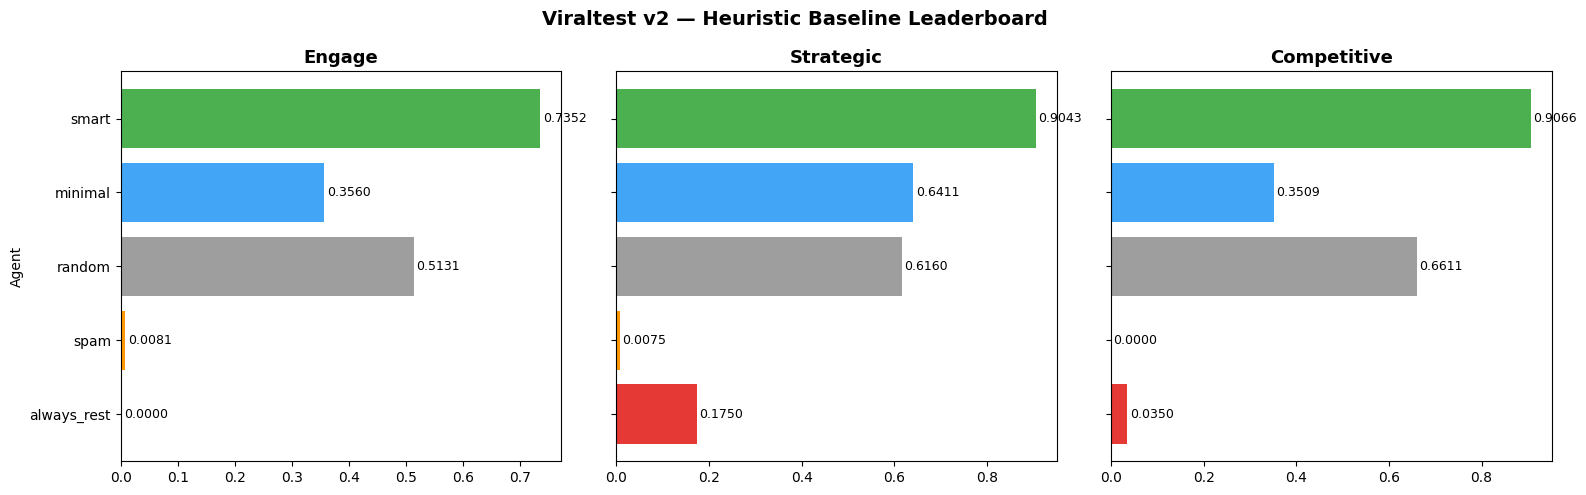

In [6]:
# Cell 6: Baseline plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
agent_names = list(BASELINE_AGENTS.keys())
colors = ['#E53935', '#FF9800', '#9E9E9E', '#42A5F5', '#4CAF50']
for i, task in enumerate(TASKS):
    scores = [baseline_results[a][task]["grader_score"] for a in agent_names]
    bars = axes[i].barh(agent_names, scores, color=colors)
    axes[i].set_title(task.replace("monthly_", "").title(), fontsize=13, fontweight='bold')
    for bar, score in zip(bars, scores):
        axes[i].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                     f"{score:.4f}", va='center', fontsize=9)
axes[0].set_ylabel("Agent")
fig.suptitle("Viraltest v2 — Heuristic Baseline Leaderboard", fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(f"{PLOTS_DIR}/baseline_leaderboard.png", dpi=150, bbox_inches='tight')
plt.show()

## Part 2: Load LLM (Qwen2.5-1.5B-Instruct)

We load the base model with 4-bit quantization to fit in free Colab's T4 GPU (16GB VRAM).

In [7]:
# Cell 7: Load model (Qwen2.5-3B bf16 on CUDA + flash-attn-2; fp16/fp32 fallback)
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"


def _has_flash_attn():
    try:
        import flash_attn  # noqa: F401
        return torch.cuda.is_available()
    except Exception:
        return False


if torch.cuda.is_available():
    dtype = torch.bfloat16
    attn_impl = "flash_attention_2" if _has_flash_attn() else "sdpa"
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    dtype, attn_impl = torch.float16, "sdpa"
else:
    dtype, attn_impl = torch.float32, "eager"

print(f"Loading {MODEL_NAME} (dtype={dtype}, attn={attn_impl})...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    dtype=dtype,
    attn_implementation=attn_impl,
    device_map="cuda:0" if torch.cuda.is_available() else None,
)
if not torch.cuda.is_available():
    model = model.to("mps") if (getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()) else model.to("cpu")

model.eval()
print(f"Model loaded. dtype={next(model.parameters()).dtype} device={next(model.parameters()).device}")
if torch.cuda.is_available():
    print(f"CUDA memory: {torch.cuda.memory_allocated()/1e9:.2f} GB")

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded. dtype=torch.bfloat16 device=cuda:0
CUDA memory: 6.17 GB


In [8]:
# Cell 8: LLM agent functions
SYSTEM_PROMPT = textwrap.dedent("""\
You are an Instagram content strategy agent. Each step is one day.
You manage a creator account over a 15-day cycle.

RESPONSE FORMAT — return ONLY valid JSON, no markdown:
{
  "tool_calls": [{"name": "<tool>", "arguments": {...}}],
  "scheduled_actions": [
    {"hour": 0-23, "action_type": "post|create_content",
     "content_type": "reel|story|carousel|text_post",
     "topic": "<string>", "tags": ["..."],
     "intent": "send_bait|save_bait|watch_bait|like_bait"}
  ],
  "notes": "strategy notes"
}

TOOLS:
- query_trends(niche)                            trending topics+tags for niche
- query_audience(segment_id)                     segment topic affinities + active hours
- query_competitor(competitor_id, window_days)   competitor recent posts
- query_tag_history(tag)                         your past signals (watch/sends/saves/likes) for a tag
- predict_engagement(scheduled_actions)          simulate a plan WITHOUT committing
- draft_review(scheduled_actions)                AI review of a draft plan
- query_creator_pool()                           list collab partners with audience overlap
- propose_collab(partner_id, content_type, hour) co-author the post at that hour (max 2/month)

ACTION SCHEMA:
- hour:         0..23 (unlisted hours = rest)
- action_type:  post (publish) | create_content (build queue, no publish)
- content_type: reel | story | carousel | text_post
- intent:       which Mosseri signal the post optimises for
                  send_bait  -> DM shares (strongest discovery signal)
                  save_bait  -> bookmarks (content quality)
                  watch_bait -> reels watch time
                  like_bait  -> likes from existing followers
- tags:         up to 5 hashtags
- topic:        free-form string
- empty scheduled_actions = full day rest""")


def format_obs(obs):
    days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    day_name = days[obs.day_of_week] if 0 <= obs.day_of_week < 7 else "?"
    signals_str = ""
    signals = getattr(obs, "engagement_signals", None)
    if signals:
        signals_str = (f"Signals: watch={signals.watch_time:.3f} "
                       f"sends={signals.sends_per_reach:.3f} "
                       f"saves={signals.saves:.3f}\n")
    tool_str = ""
    for tr in getattr(obs, "tool_results", []):
        if tr.success:
            tool_str += f"  {tr.name}: {json.dumps(tr.data)}\n"
    if not tool_str:
        tool_str = "  (none)\n"
    return (f"Day: {day_name} | days_elapsed={obs.days_elapsed}\n"
            f"Energy: {obs.creator_energy:.2f} | Followers: {obs.follower_count}\n"
            f"Engagement: {obs.engagement_rate:.3f} | Queue: {obs.content_queue_size}\n"
            f"{signals_str}"
            f"Tool results:\n{tool_str}"
            f"Plan your actions (JSON only):")


def is_well_formed_response(text):
    try:
        t = text.strip()
        if "```" in t:
            t = "\n".join(l for l in t.split("\n") if not l.strip().startswith("```")).strip()
        s, e = t.find("{"), t.rfind("}") + 1
        d = json.loads(t[s:e])
        for tc in d.get("tool_calls", []):
            if not isinstance(tc, dict) or not isinstance(tc.get("arguments", {}), dict):
                return False
        return True
    except Exception:
        return False


def parse_model_output(text):
    text = text.strip()
    if "```" in text:
        lines = [l for l in text.split("\n") if not l.strip().startswith("```")]
        text = "\n".join(lines).strip()
    start, end = text.find("{"), text.rfind("}") + 1
    if start >= 0 and end > start:
        text = text[start:end]
    try:
        data = json.loads(text)
    except Exception:
        return ViraltestAction(scheduled_actions=[])
    tool_calls = []
    for tc in data.get("tool_calls", []):
        if not isinstance(tc, dict) or "name" not in tc:
            continue
        args = tc.get("arguments", {})
        if isinstance(args, list) and args and isinstance(args[0], dict):
            args = args[0]
        if not isinstance(args, dict):
            continue
        try:
            tool_calls.append(ToolCall(name=tc["name"], arguments=args))
        except Exception:
            pass
    scheduled = []
    for a in data.get("scheduled_actions", []):
        try:
            scheduled.append(ScheduledAction(**a))
        except Exception:
            pass
    return ViraltestAction(
        tool_calls=tool_calls,
        scheduled_actions=scheduled,
        notes=data.get("notes"),
    )


def _infer_model_device(m):
    """Works for single/multi-device models (Peft, 4-bit) where m.device may be missing."""
    p = next(m.parameters(), None)
    if p is not None:
        return p.device
    d = getattr(m, "device", None)
    if d is not None:
        return d
    return torch.device("cpu")


def _build_chat(history, prompt):
    msgs = [{"role": "system", "content": SYSTEM_PROMPT}]
    msgs.extend(history[-14:])
    msgs.append({"role": "user", "content": prompt})
    return msgs


def _batched_generate(mdl, tok, prompts, temperature=0.7, max_new_tokens=512):
    enc = tok(prompts, return_tensors="pt", padding=True, truncation=False).to(_infer_model_device(mdl))
    with torch.no_grad():
        out = mdl.generate(
            **enc, max_new_tokens=max_new_tokens, temperature=temperature,
            do_sample=True, top_p=0.9, pad_token_id=tok.pad_token_id,
        )
    resps = tok.batch_decode(out[:, enc["input_ids"].shape[1]:], skip_special_tokens=True)
    return resps, enc["input_ids"].shape[1]


def run_llm_episodes_batched(mdl, tok, tasks_seeds, verbose=True):
    """Run N episodes in parallel. tasks_seeds: list of (task, seed). One batched generate per day."""
    n = len(tasks_seeds)
    envs = [ViraltestEnvironment() for _ in range(n)]
    obss = [envs[i].reset(task=t, seed=s) for i, (t, s) in enumerate(tasks_seeds)]
    histories = [[] for _ in range(n)]
    rewards = [[] for _ in range(n)]
    energies = [[obs.creator_energy] for obs in obss]
    pairs = [[] for _ in range(n)]
    done_mask = [obs.done for obs in obss]
    rest_resp = '{"scheduled_actions": []}'

    for day in range(1, TASK_HORIZON + 1):
        active = [i for i in range(n) if not done_mask[i] and obss[i].creator_energy > 0.25]
        rest = [i for i in range(n) if not done_mask[i] and obss[i].creator_energy <= 0.25]
        if not active and not rest:
            break

        resps_by_idx = {}
        if active:
            prompts = [format_obs(obss[i]) for i in active]
            chats = [_build_chat(histories[i], p) for i, p in zip(active, prompts)]
            texts = [tok.apply_chat_template(c, tokenize=False, add_generation_prompt=True) for c in chats]
            resps, ptok = _batched_generate(mdl, tok, texts)
            if verbose:
                print(f"  D{day:2d}: batch={len(active)} rest={len(rest)} prompt_tok={ptok}")
            for j, i in enumerate(active):
                resps_by_idx[i] = (resps[j], prompts[j])
        for i in rest:
            resps_by_idx[i] = (rest_resp, format_obs(obss[i]))

        for i in range(n):
            if done_mask[i] or i not in resps_by_idx:
                continue
            resp, prompt = resps_by_idx[i]
            action = parse_model_output(resp)
            pairs[i].append({"prompt": prompt, "response": resp})
            obss[i] = envs[i].step(action)
            r = obss[i].reward or 0.0
            rewards[i].append(r)
            energies[i].append(obss[i].creator_energy)
            histories[i].extend([
                {"role": "user", "content": prompt},
                {"role": "assistant", "content": resp},
            ])
            if obss[i].done:
                done_mask[i] = True

    GAMMA, TERMINAL_W = 0.95, 5.0
    results = []
    for i, (task, seed) in enumerate(tasks_seeds):
        gs = (obss[i].metadata or {}).get("grader_score", 0.0)
        rets = [0.0] * len(rewards[i])
        G = gs * TERMINAL_W
        for t in reversed(range(len(rewards[i]))):
            G = rewards[i][t] + GAMMA * G
            rets[t] = G
        for k, pr in enumerate(pairs[i]):
            pr["return"] = rets[k] if k < len(rets) else 0.0
        results.append({
            "task": task, "seed": seed, "grader_score": gs,
            "total_reward": sum(rewards[i]), "final_energy": obss[i].creator_energy,
            "rewards": rewards[i], "returns": rets, "energies": energies[i],
            "pairs": pairs[i], "follower_delta": obss[i].follower_count - 10000,
            "burned_out": obss[i].creator_energy <= 0,
        })
    return results


def run_llm_episode(mdl, tok, task, seed=42, verbose=False):
    return run_llm_episodes_batched(mdl, tok, [(task, seed)], verbose=verbose)[0]


print("LLM agent functions defined (batched).")

LLM agent functions defined (batched).


## Part 3: Untrained LLM Baseline (“Before”)

Run the base model with NO fine-tuning. This establishes ground truth.

In [9]:
# Cell 9: Run untrained model (batched: all 3 tasks in parallel envs)
print("Running UNTRAINED base model on all tasks (batched)...")
print("=" * 60)

t0 = time.time()
results = run_llm_episodes_batched(model, tokenizer, [(t, 42) for t in TASKS], verbose=True)
before_results = {r["task"]: r for r in results}

print("\n" + "=" * 60)
print(f"BEFORE TRAINING (took {time.time()-t0:.1f}s):")
for t in TASKS:
    print(f"  {t}: grader={before_results[t]['grader_score']:.4f}")

Running UNTRAINED base model on all tasks (batched)...


  D 1: batch=3 rest=0 prompt_tok=495


  D 2: batch=3 rest=0 prompt_tok=706


  D 3: batch=3 rest=0 prompt_tok=979


  D 4: batch=3 rest=0 prompt_tok=1206


...

  D11: batch=3 rest=0 prompt_tok=2263


  D12: batch=3 rest=0 prompt_tok=2274


  D13: batch=3 rest=0 prompt_tok=2280


  D14: batch=3 rest=0 prompt_tok=2285


  D15: batch=3 rest=0 prompt_tok=2284

BEFORE TRAINING (took 84.9s):
  monthly_engage: grader=0.5642
  monthly_strategic: grader=0.5903
  monthly_competitive: grader=0.8313


## Part 4: LoRA Fine-Tuning (Real Weight Updates)

This is the core training loop. For each round:
1. Collect episodes with current model
2. Score each (prompt, response) pair by episode reward
3. Keep top 50% highest-reward samples
4. Fine-tune LoRA weights via SFT on those samples

The model's actual weights change via gradient descent — this is real training.

In [10]:
# Cell 10: Attach LoRA adapter
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    task_type=TaskType.CAUSAL_LM, bias="none",
)

model.enable_input_require_grads()
peft_model = get_peft_model(model, lora_config)
peft_model.print_trainable_parameters()

trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607


In [11]:
# Cell 11: Training loop
from trl import SFTTrainer, SFTConfig
from datasets import Dataset

NUM_ROUNDS = 4
EPISODES_PER_ROUND = 6
TOP_K_FRACTION = 0.5

training_log = {
    "round": [], "avg_episode_reward": [], "max_episode_reward": [],
    "min_episode_reward": [], "avg_grader": [], "max_grader": [],
    "n_training_samples": [], "train_loss": [],
}

t_start = time.time()

for round_idx in range(1, NUM_ROUNDS + 1):
    print(f"\n{'=' * 60}")
    print(f"TRAINING ROUND {round_idx}/{NUM_ROUNDS}")
    print(f"{'=' * 60}")

    peft_model.eval()
    tasks_seeds = [(TASKS[ep % len(TASKS)], 42 + (round_idx - 1) * 100 + ep) for ep in range(EPISODES_PER_ROUND)]
    t_roll = time.time()
    results = run_llm_episodes_batched(peft_model, tokenizer, tasks_seeds, verbose=False)
    print(f"  Rollouts: {len(results)} eps × {TASK_HORIZON} days in {time.time()-t_roll:.1f}s")

    all_pairs, episode_rewards, episode_graders = [], [], []
    for ep, result in enumerate(results):
        ep_reward = result["total_reward"] + 2.0 * result["grader_score"]
        episode_rewards.append(ep_reward)
        episode_graders.append(result["grader_score"])
        kept = 0
        for pr in result["pairs"]:
            if not is_well_formed_response(pr["response"]):
                continue
            text = (f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
                    f"<|im_start|>user\n{pr['prompt']}<|im_end|>\n"
                    f"<|im_start|>assistant\n{pr['response']}<|im_end|>")
            all_pairs.append({"text": text, "reward": pr["return"]})
            kept += 1
        print(f"  ep {ep+1}/{EPISODES_PER_ROUND}: {result['task'].split('_')[-1]:>11s} "
              f"grader={result['grader_score']:.4f} reward={ep_reward:.3f} kept={kept}/{len(result['pairs'])}")

    avg_r = float(np.mean(episode_rewards))
    avg_g = float(np.mean(episode_graders))
    print(f"  Avg reward={avg_r:.3f} Avg grader={avg_g:.4f} | total pairs={len(all_pairs)}")
    if not all_pairs:
        print("  WARNING: 0 well-formed pairs collected; skipping SFT.")
        continue

    threshold = np.percentile([p["reward"] for p in all_pairs], (1 - TOP_K_FRACTION) * 100)
    filtered = [p for p in all_pairs if p["reward"] >= threshold] or all_pairs
    print(f"  Filtered to {len(filtered)}/{len(all_pairs)} samples (return >= {threshold:.3f})")

    dataset = Dataset.from_list([{"text": p["text"]} for p in filtered])

    # SFT training (real gradient updates)
    sft_config = SFTConfig(
        output_dir=f"./checkpoints/round_{round_idx}",
        num_train_epochs=2,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=2,
        learning_rate=2e-5,
        warmup_ratio=0.1,
        logging_steps=1,
        save_strategy="no",
        max_length=4096,
        bf16=True,
        report_to="none",
    )

    peft_model.train()
    trainer = SFTTrainer(
        model=peft_model, processing_class=tokenizer,
        train_dataset=dataset, args=sft_config,
    )
    train_result = trainer.train()
    loss = train_result.training_loss
    print(f"  Training loss: {loss:.4f}")

    training_log["round"].append(round_idx)
    training_log["avg_episode_reward"].append(round(float(avg_r), 3))
    training_log["max_episode_reward"].append(round(float(max(episode_rewards)), 3))
    training_log["min_episode_reward"].append(round(float(min(episode_rewards)), 3))
    training_log["avg_grader"].append(round(float(avg_g), 4))
    training_log["max_grader"].append(round(float(max(episode_graders)), 4))
    training_log["n_training_samples"].append(len(filtered))
    training_log["train_loss"].append(round(loss, 4))

elapsed = time.time() - t_start
print(f"\nTraining complete in {elapsed/60:.1f} min")
print(pd.DataFrame(training_log).to_string(index=False))


TRAINING ROUND 1/4


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Rollouts: 6 eps × 15 days in 299.0s
  ep 1/6:      engage grader=0.5430 reward=4.047 kept=15/15
  ep 2/6:   strategic grader=0.3790 reward=3.295 kept=15/15
  ep 3/6: competitive grader=0.0332 reward=2.316 kept=15/15
  ep 4/6:      engage grader=0.6470 reward=4.348 kept=15/15
  ep 5/6:   strategic grader=0.1750 reward=2.600 kept=1/15
  ep 6/6: competitive grader=0.0332 reward=2.316 kept=15/15
  Avg reward=3.154 Avg grader=0.3017 | total pairs=76
  Filtered to 38/76 samples (return >= 2.370)


Adding EOS to train dataset:   0%|          | 0/38 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/38 [00:00<?, ? examples/s]

...

  Rollouts: 6 eps × 15 days in 199.4s
  ep 1/6:      engage grader=0.0793 reward=2.443 kept=15/15
  ep 2/6:   strategic grader=0.5243 reward=4.527 kept=15/15
  ep 3/6: competitive grader=0.0350 reward=2.320 kept=15/15
  ep 4/6:      engage grader=0.3129 reward=3.254 kept=15/15
  ep 5/6:   strategic grader=0.4373 reward=3.809 kept=15/15
  ep 6/6: competitive grader=0.2871 reward=3.410 kept=15/15
  Avg reward=3.294 Avg grader=0.2793 | total pairs=90
  Filtered to 45/90 samples (return >= 2.252)


Adding EOS to train dataset:   0%|          | 0/45 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/45 [00:00<?, ? examples/s]

Step,Training Loss
1,2.101937
2,2.069137
3,2.114893
4,2.032242
5,2.023777
6,1.962225
7,1.979426
8,1.921424
9,1.907600
10,1.893878


  Training loss: 1.9805

Training complete in 21.5 min
 round  avg_episode_reward  max_episode_reward  min_episode_reward  avg_grader  max_grader  n_training_samples  train_loss
     1               3.154               4.348               2.316      0.3017      0.6470                  38      2.6893
     2               2.855               3.710               2.249      0.2058      0.5125                  37      2.5540
     3               2.969               4.140               2.250      0.2041      0.4656                  45      2.0757
     4               3.294               4.527               2.320      0.2793      0.5243                  45      1.9805


## Part 5: Trained LLM Evaluation (“After”)

Same model, same seeds, same environment — but now with updated LoRA weights.

In [12]:
# Cell 12: Run trained model (batched)
print("Running TRAINED model on all tasks (batched)...")
print("=" * 60)

peft_model.eval()
t0 = time.time()
results = run_llm_episodes_batched(peft_model, tokenizer, [(t, 42) for t in TASKS], verbose=True)
after_results = {r["task"]: r for r in results}

print("\n" + "=" * 60)
print(f"AFTER TRAINING (took {time.time()-t0:.1f}s):")
for t in TASKS:
    print(f"  {t}: grader={after_results[t]['grader_score']:.4f}")

Running TRAINED model on all tasks (batched)...


  D 1: batch=3 rest=0 prompt_tok=495


  D 2: batch=3 rest=0 prompt_tok=786


  D 3: batch=3 rest=0 prompt_tok=1075


  D 4: batch=3 rest=0 prompt_tok=1374


...

  D11: batch=3 rest=0 prompt_tok=3998


  D12: batch=3 rest=0 prompt_tok=4302


  D13: batch=3 rest=0 prompt_tok=4503


  D14: batch=3 rest=0 prompt_tok=4635


  D15: batch=3 rest=0 prompt_tok=4712

AFTER TRAINING (took 428.2s):
  monthly_engage: grader=0.1071
  monthly_strategic: grader=0.3174
  monthly_competitive: grader=0.5233


## Part 6: Result Plots — Real Training Evidence

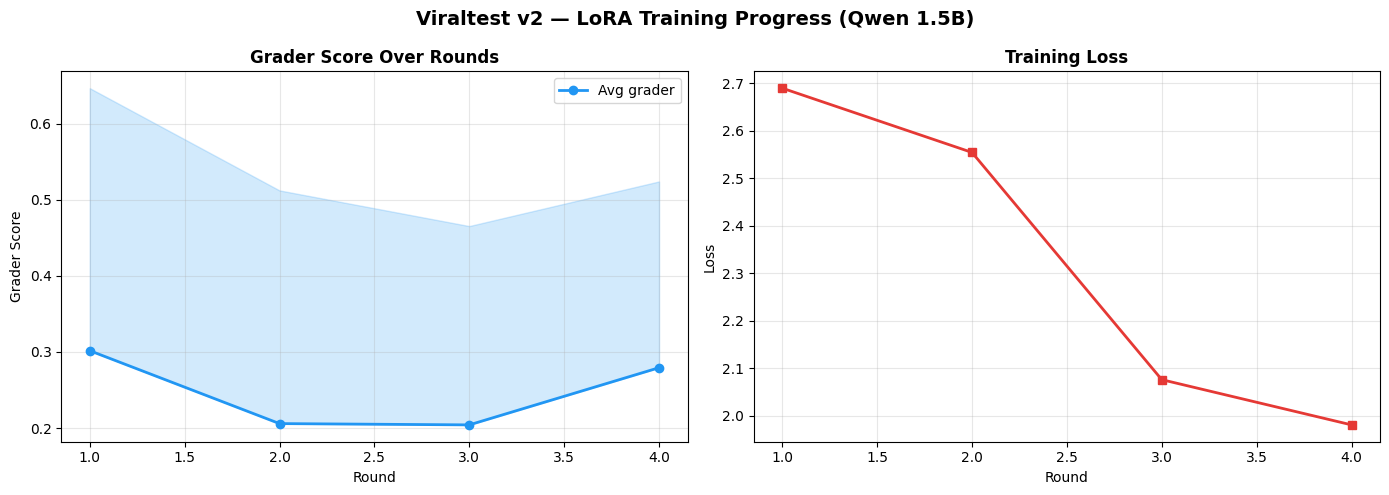

In [13]:
# Cell 13: Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rounds = training_log["round"]

axes[0].plot(rounds, training_log["avg_grader"], 'o-', color='#2196F3', lw=2, label='Avg grader')
axes[0].fill_between(rounds, training_log["avg_grader"],
                     training_log["max_grader"], alpha=0.2, color='#2196F3')
axes[0].set_xlabel('Round'); axes[0].set_ylabel('Grader Score')
axes[0].set_title('Grader Score Over Rounds', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(rounds, training_log["train_loss"], 's-', color='#E53935', lw=2)
axes[1].set_xlabel('Round'); axes[1].set_ylabel('Loss')
axes[1].set_title('Training Loss', fontweight='bold')
axes[1].grid(True, alpha=0.3)

fig.suptitle('Viraltest v2 — LoRA Training Progress (Qwen 1.5B)', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{PLOTS_DIR}/reward_curve.png', dpi=150, bbox_inches='tight')
plt.show()

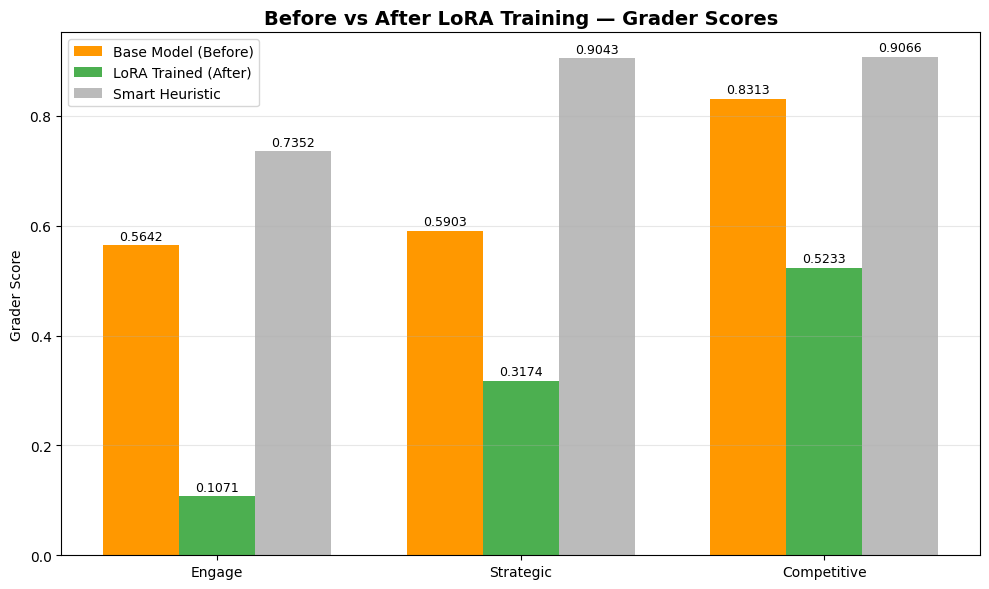

In [14]:
# Cell 14: Before vs After
task_labels = [t.replace('monthly_', '').title() for t in TASKS]
x = np.arange(len(TASKS))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
b_scores = [before_results[t]["grader_score"] for t in TASKS]
a_scores = [after_results[t]["grader_score"] for t in TASKS]
s_scores = [baseline_results["smart"][t]["grader_score"] for t in TASKS]

ax.bar(x - w, b_scores, w, label='Base Model (Before)', color='#FF9800')
ax.bar(x, a_scores, w, label='LoRA Trained (After)', color='#4CAF50')
ax.bar(x + w, s_scores, w, label='Smart Heuristic', color='#9E9E9E', alpha=0.7)

ax.set_ylabel('Grader Score'); ax.set_xticks(x); ax.set_xticklabels(task_labels)
ax.set_title('Before vs After LoRA Training — Grader Scores', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

for container in ax.containers:
    for bar in container:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.005,
                    f'{h:.4f}', ha='center', va='bottom', fontsize=9)

fig.tight_layout()
fig.savefig(f'{PLOTS_DIR}/before_after.png', dpi=150, bbox_inches='tight')
plt.show()

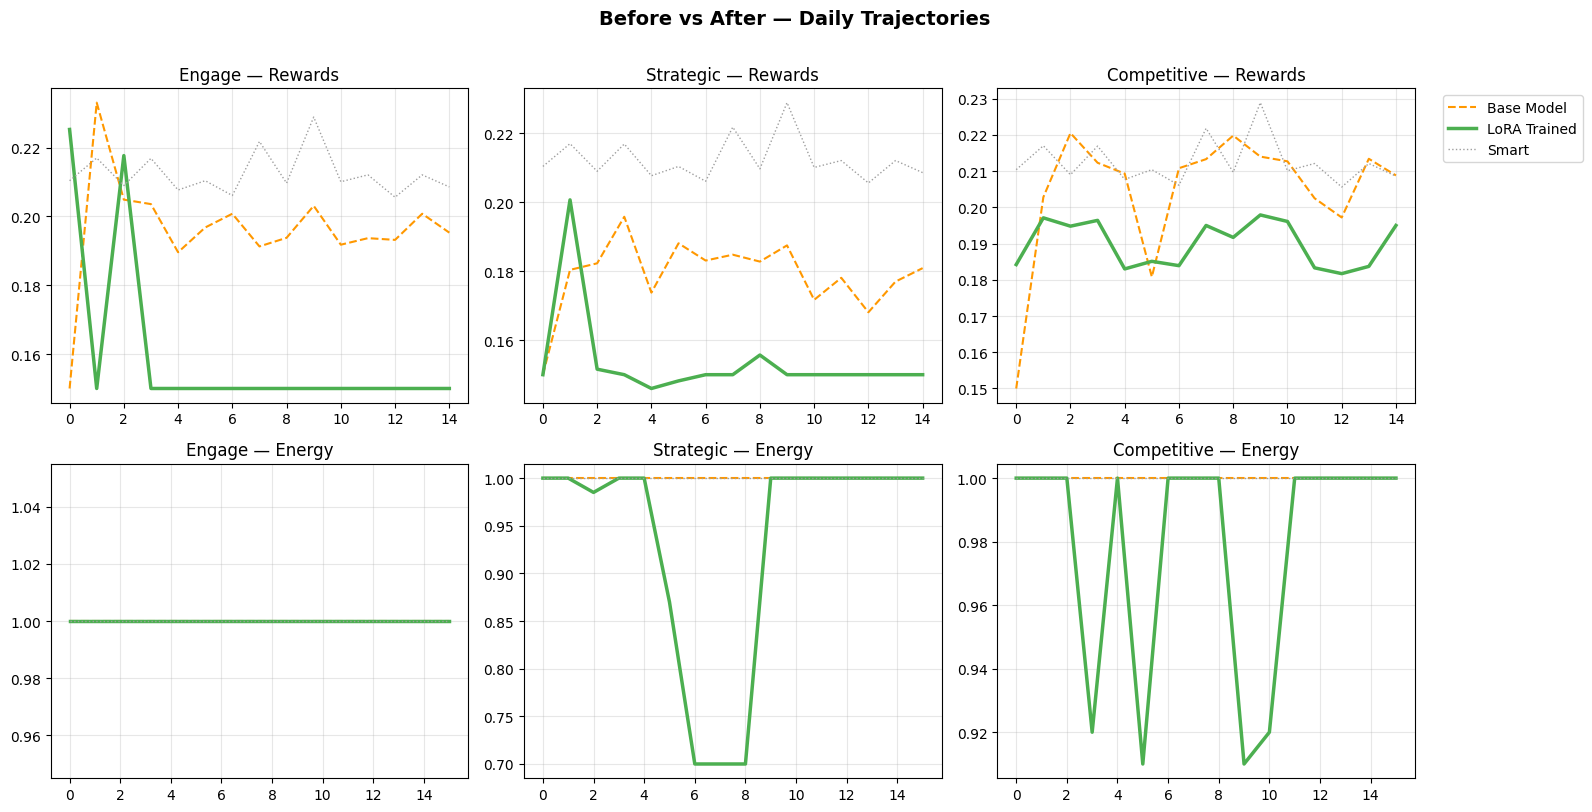

In [15]:
# Cell 15: Trajectory comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
comparisons = [
    ("Base Model", before_results, '#FF9800', '--'),
    ("LoRA Trained", after_results, '#4CAF50', '-'),
]
for i, task in enumerate(TASKS):
    for label, res, color, ls in comparisons:
        lw = 2.5 if 'Trained' in label else 1.5
        axes[0, i].plot(res[task]["rewards"], label=label, color=color, lw=lw, ls=ls)
        axes[1, i].plot(res[task]["energies"], label=label, color=color, lw=lw, ls=ls)
    sr = baseline_results["smart"][task]
    axes[0, i].plot(sr["rewards"], label="Smart", color='#9E9E9E', lw=1, ls=':')
    axes[1, i].plot(sr["energies"], label="Smart", color='#9E9E9E', lw=1, ls=':')
    t_name = task.replace('monthly_', '').title()
    axes[0, i].set_title(f"{t_name} — Rewards"); axes[0, i].grid(True, alpha=0.3)
    axes[1, i].set_title(f"{t_name} — Energy"); axes[1, i].grid(True, alpha=0.3)
axes[0, 2].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
fig.suptitle('Before vs After — Daily Trajectories', fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(f'{PLOTS_DIR}/training_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 7: Summary & Export

In [16]:
# Cell 16: Final summary
print("=" * 67)
print("FINAL RESULTS")
print("=" * 67)
print(f"\n{'Task':<25s} {'Before':>10s} {'After':>10s} {'Delta':>10s} {'Smart':>10s}")
print("-" * 67)
for task in TASKS:
    b = before_results[task]["grader_score"]
    a = after_results[task]["grader_score"]
    s = baseline_results["smart"][task]["grader_score"]
    print(f"{task:<25s} {b:>10.4f} {a:>10.4f} {a-b:>+10.4f} {s:>10.4f}")

avg_b = np.mean([before_results[t]["grader_score"] for t in TASKS])
avg_a = np.mean([after_results[t]["grader_score"] for t in TASKS])
avg_s = np.mean([baseline_results["smart"][t]["grader_score"] for t in TASKS])
print("-" * 67)
print(f"{'AVERAGE':<25s} {avg_b:>10.4f} {avg_a:>10.4f} {avg_a-avg_b:>+10.4f} {avg_s:>10.4f}")

summary = {
    "model": MODEL_NAME,
    "training": "LoRA SFT (real weight updates)",
    "rounds": NUM_ROUNDS, "episodes_per_round": EPISODES_PER_ROUND,
    "before": {t: before_results[t]["grader_score"] for t in TASKS},
    "after": {t: after_results[t]["grader_score"] for t in TASKS},
    "smart_heuristic": {t: baseline_results["smart"][t]["grader_score"] for t in TASKS},
    "improvement": {t: after_results[t]["grader_score"] - before_results[t]["grader_score"] for t in TASKS},
    "training_log": training_log,
}
with open(f"{PLOTS_DIR}/training_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

pd.DataFrame(training_log).to_csv(f"{PLOTS_DIR}/training_log.csv", index=False)

print(f"\nSaved to {PLOTS_DIR}/")
print("All results are from real LoRA weight updates on real environment runs.")

FINAL RESULTS

Task                          Before      After      Delta      Smart
-------------------------------------------------------------------
monthly_engage                0.5642     0.1071    -0.4571     0.7352
monthly_strategic             0.5903     0.3174    -0.2729     0.9043
monthly_competitive           0.8313     0.5233    -0.3080     0.9066
-------------------------------------------------------------------
AVERAGE                       0.6619     0.3159    -0.3460     0.8487

Saved to /work/plots/
All results are from real LoRA weight updates on real environment runs.


In [17]:
# Cell 17: Save adapter
save_path = "./viraltest_trained_adapter"
peft_model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"LoRA adapter saved to {save_path}")
print("Load with: PeftModel.from_pretrained(base_model, save_path)")

LoRA adapter saved to ./viraltest_trained_adapter
Load with: PeftModel.from_pretrained(base_model, save_path)
